<a href="https://colab.research.google.com/github/gnganesh99/NN_Error/blob/ayush_dev/notebooks/STM/stm_ms_analyze_spectrum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports and Functions

In [1]:
#Installs on colab
def running_on_colab():
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

if running_on_colab():
    print("Running on Colab. Installing dependencies...")
    !pip install -q atomai neuraloperator ipympl ipywidgets hoffmanstmpy

    from google.colab import output
    output.enable_custom_widget_manager()

    !git clone -b ayush_dev --single-branch https://github.com/gnganesh99/NN_Error.git
    %cd NN_Error

    print("Colab setup complete.")

Running on Colab. Installing dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 kB 17.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.0/179.0 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.3/145.3 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 127.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 135.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import os
from scipy.ndimage import zoom
import pandas as pd


try:
    get_ipython().run_line_magic("matplotlib", "widget")
except (ValueError, RuntimeError):
    get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt


# Make package and notebook-local helper modules importable whether this starts in repo root or notebooks/
repo_root = Path.cwd() if (Path.cwd() / "src" / "nnerror").exists() else Path.cwd().parent.parent
src_root = str((repo_root / "src").resolve())
nb_root = str((repo_root / "notebooks"/"STM").resolve())
for import_root in (src_root, nb_root):
    if import_root not in sys.path:
        sys.path.insert(0, import_root)




from nnerror.networks import FNO_im2spec, CustomDecoder, im2spec, im2spec_attn, FNO_im2spec_attn
from nnerror.networks.custom_nn import CustomCNN
from nnerror.training_functions import err_estimation, train_model, predict_spectra, norm_0to1, predict_posterior, append_training_set
from nnerror.plot_functions import plot_only_training_loss, plot_training_loss, \
    plot_error_prediction, plot_spectra, plot_error_prediction_3d, plot_scale_slider, plot_latent_space, cluster_latent_space, plot_latent_distribution, plot_scale_specific_error_and_acquisition_maps
from nnerror.utils import append_multiscale_data, edges_zeroed_image, interpolated_center_crop, paired_images_spectra_1
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [3]:
from nnerror.training_functions import distance_acq_fn, append_training_set, train_model, err_estimation, predict_spectra
from nnerror.plot_functions import plot_error_prediction, plot_spectra, plot_error_prediction_3d
from nnerror.networks import CustomDecoder # Assuming CustomDecoder is needed for error_model retraining
from sklearn.model_selection import train_test_split # Added import for train_test_split
import pandas as pd # Import pandas for DataFrame operations

In [4]:
from stm_utils import Sxm_Image
from CITS_Class import CITS_Analysis


In [5]:
class Norm_G:
    """Gaussian normalization using mean and standard deviation."""

    def __init__(self, data=None, mean=None, std=None, axis=0, eps=1e-8):
        self.data = data
        self.axis = axis
        self.eps = eps

        if data is not None:
            self.mean = np.mean(data, axis=axis, keepdims=True)
            self.std = np.std(data, axis=axis, keepdims=True)
        elif mean is not None and std is not None:
            self.mean = mean
            self.std = std
        else:
            raise ValueError("Either data or both mean and std must be provided.")

        self.std = np.where(self.std < eps, eps, self.std)

    def normalize(self, data=None):
        """Normalize data using stored mean and std."""
        if data is None:
            data = self.data
        return (data - self.mean) / self.std

    def denormalize(self, normalized_data):
        """Denormalize data using stored mean and std."""
        return normalized_data * self.std + self.mean


class Norm_0to1:
    """Normalization to the range [0, 1]."""

    def __init__(self, data=None, min_val=None, max_val=None, axis=0, eps=1e-8):
        self.data = data
        self.axis = axis
        self.eps = eps

        if data is not None:
            self.min_val = np.min(data, axis=axis, keepdims=True)
            self.max_val = np.max(data, axis=axis, keepdims=True)
        elif min_val is not None and max_val is not None:
            self.min_val = min_val
            self.max_val = max_val
        else:
            raise ValueError("Either data or both min_val and max_val must be provided.")

        self.data_range = np.where(
            (self.max_val - self.min_val) < eps,
            eps,
            self.max_val - self.min_val
        )

    def normalize(self, data=None):
        """Normalize data using stored min and max."""
        if data is None:
            if self.data is None:
                raise ValueError("No data provided to normalize.")
            data = self.data

        return (data - self.min_val) / self.data_range

    def denormalize(self, normalized_data):
        """Denormalize data using stored min and max."""
        return normalized_data * self.data_range + self.min_val

In [6]:
def get_model(model_type, in_dim, out_dim, latent_dim = 3, device = None):
    # ----------------------------
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if model_type == "im2spec":
        model = im2spec(feature_size=in_dim, target_size=out_dim, latent_dim=latent_dim).to(device)

    elif model_type == "FNO":
        model = FNO_im2spec(
            target_size=out_dim,
            latent_dim=latent_dim,
            hidden_channels=32,
            n_modes=(16, 16),
            n_layers=4,
        ).to(device)

    elif model_type == "im2spec_attn":
        model = im2spec_attn(feature_size=in_dim, target_size=out_dim, latent_dim=latent_dim).to(device)
    elif model_type == "FNO_attn":
        model = FNO_im2spec_attn(
            target_size=out_dim,
            latent_dim=latent_dim,
            hidden_channels=32,
            n_modes=(16, 16),
            n_layers=4,
        ).to(device)

    else:
        raise ValueError(f"Unknown model type: {model_type}")

    return model

In [20]:

def augment_images_by_indices(indices, images, spectra, coordinates, WS_init, WS, d_WS, append_image_type = None, scale_type = "multi_scale"):


    images = images[indices]
    spectra = spectra[indices]
    coordinates = coordinates[indices]


    if scale_type == "single_scale":
        image_scale = images.shape[-1]  # Assuming the last dimension corresponds to the scale
        coordinates = np.hstack([coordinates, image_scale * np.ones((coordinates.shape[0], 1))])
        return images, spectra, coordinates

    if append_image_type is None:
        raise ValueError("append_image_type must be 'pad' or 'interpolate'.")

    images_aug, spectra_aug, coords_aug = append_multiscale_data(images, spectra, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=coordinates,
                                                            append_image_type=append_image_type)


    return images_aug, spectra_aug, coords_aug


def reduce_errors_and_coords(predicted_errors, scale_coordinates):

    df_errors = pd.DataFrame({
        "x": scale_coordinates[:, 0],
        "y": scale_coordinates[:, 1],
        "scale": scale_coordinates[:, 2],
        "error": predicted_errors,
    })

    reduced = (
        df_errors.loc[df_errors.groupby(["x", "y"])["error"].idxmin()]
        .sort_values(["x", "y"])
        .reset_index(drop=True)
    )

    errors = reduced["error"].to_numpy()
    coords_reduced = reduced[["x", "y", "scale"]].to_numpy()

    return errors, coords_reduced



def plot_reduced_errors_and_scales(errors, coords_reduced, aq_indices=None, nm_per_pixel=1.0):
    xs = coords_reduced[:, 0] * nm_per_pixel
    ys = coords_reduced[:, 1] * nm_per_pixel
    scales = coords_reduced[:, 2] * nm_per_pixel

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sc0 = axes[0].scatter(xs, ys, c=errors, s=80)
    axes[0].set_title("Reduced Minimum Errors, mean = {:.3f}".format(np.mean(errors)))
    axes[0].set_xlabel("x (nm)")
    axes[0].set_ylabel("y (nm)")
    axes[0].set_aspect("equal")
    plt.colorbar(sc0, ax=axes[0], label="Minimum Error")

    sc1 = axes[1].scatter(xs, ys, c=scales, s=80)
    axes[1].set_title("Best Scale at Each (x, y)")
    axes[1].set_xlabel("x (nm)")
    axes[1].set_ylabel("y (nm)")
    axes[1].set_aspect("equal")
    plt.colorbar(sc1, ax=axes[1], label="Best Scale (nm)")

    if aq_indices is not None and len(aq_indices) > 0:
        aq_indices = np.asarray(aq_indices, dtype=int)

        axes[0].scatter(
            xs[aq_indices],
            ys[aq_indices],
            marker="x",
            s=120,
            linewidths=2,
            label="Acquisition points"
        )
        axes[0].legend()

    plt.tight_layout()
    plt.show()


def plot_spectra_grid(spectra, predicted_spectra, error_values, error_type, plots_per_row=5, voltages=None):
    """Plot original and predicted spectra in rows of up to five plots."""
    n_plots = len(spectra)
    if not (n_plots == len(predicted_spectra) == len(error_values)):
        raise ValueError("spectra, predicted_spectra, and error_values must have the same length.")
    if n_plots == 0:
        return

    error_label = {
        "L1": "L1 error",
        "L2": "L2 error",
        "cos": "Cosine error",
    }.get(error_type, f"{error_type} error")
    n_rows = int(np.ceil(n_plots / plots_per_row))
    fig, axes = plt.subplots(
        n_rows, plots_per_row,
        figsize=(10 * plots_per_row, 10 * n_rows), # Increased figure size again
        squeeze=False
    )

    for idx, (ax, spectrum, predicted_spectrum, error_value) in enumerate(zip(
        axes.flat, spectra, predicted_spectra, error_values
    )):
        spectrum = np.asarray(spectrum).squeeze()
        predicted_spectrum = np.asarray(predicted_spectrum).squeeze()

        if voltages is not None:
            x_plot = voltages
            ax.set_xlabel('Voltage', fontsize=34) # Increased font size
            ax.set_xticks([-1, 1])
        else:
            x_plot = np.arange(len(spectrum))
            ax.set_xlabel('Index', fontsize=28) # Increased font size

        ax.plot(x_plot, spectrum, 'o-', color='black', alpha=0.6, label='original_spectrum')
        ax.plot(
            x_plot, predicted_spectrum, linewidth=3,
            label=f'Predicted\n{error_label}: {float(error_value):.4f}'
        )
        ax.legend(fontsize=32) # Increased legend font size

        # Set y-axis label only for the leftmost plot in each row
        if idx % plots_per_row == 0:
            ax.set_ylabel('Current (A.U.)', fontsize=34)
        else:
            ax.set_ylabel('')

        ax.tick_params(axis='x', labelsize=24) # Increased x-tick label font size
        ax.tick_params(axis='y', labelsize=24) # Increased y-tick label font size

    for ax in axes.flat[n_plots:]:
        ax.set_visible(False)

    fig.tight_layout()
    plt.show()


def find_row_indices(original, subset):
    # Map each row (as a tuple) to its index in the original array
    row_to_index = {tuple(row): i for i, row in enumerate(original)}

    # Look up each row in the subset
    indices = np.array([row_to_index[tuple(row)] for row in subset])

    return indices

import h5py
import numpy as np

def save_h5(filename, data_dict):
    """Save a dictionary of arrays to an HDF5 file."""
    with h5py.File(filename, "w") as f:
        for key, value in data_dict.items():
            f.create_dataset(key, data=value)


def load_h5(filename):
    """Load a dictionary of arrays from an HDF5 file."""
    data_dict = {}
    with h5py.File(filename, "r") as f:
        for key in f.keys():
            data_dict[key] = f[key][()]
    return data_dict



def save_h5_ragged(filename, data_dict):
    with h5py.File(filename, "w") as f:
        for key, value_list in data_dict.items():
            group = f.create_group(key)

            for i, value in enumerate(value_list):
                group.create_dataset(str(i), data=np.asarray(value))


def load_h5_ragged(filename):
    data_dict = {}

    with h5py.File(filename, "r") as f:
        for key in f.keys():
            group = f[key]

            values = []
            for i in range(len(group)):
                values.append(group[str(i)][()].tolist())

            data_dict[key] = values

    return data_dict


def default_append_image_type(model_type):
    if model_type in ("im2spec", "im2spec_attn"):
        return "pad"
    return "interpolate"


# Get data

In [8]:
data_folder = r"data/large_area" if not running_on_colab() else r"notebooks/STM/data/large_area"

img_sxm = os.path.join(data_folder, "EnZn2As2017.sxm")
spectra_sxm = os.path.join(data_folder, "EuZn2As2003.3ds")
#Get the morphology image
full_image = Sxm_Image(img_sxm).image()
full_image = norm_0to1(full_image)

#Get the current spectra
cits_obj = CITS_Analysis(spectra_sxm)
hyperspectra = cits_obj.current

full_image.shape, hyperspectra.shape

File import successful.


((512, 512), (80, 250, 121))

In [9]:
WS = 32
WS_init = 4
d_WS = 4
n_epochs_im2spec = 200
n_epochs_error = 200
error_type = "L1" # "L1", "L2", or "cos"
model_type = 'im2spec'
append_image_type = "pad" if model_type == 'im2spec' or 'im2spec_attn' or 'CustomCNN' else "interpolate" #pad, interpolate
use_swa = True
latent_dim = 5
last_swa_epochs = 100
scale = "singlescale" # "singlescale"
nm_per_pixel = 0.4833

(1024, 32, 32) (1024, 121) (1024, 2)
[30. 30.]


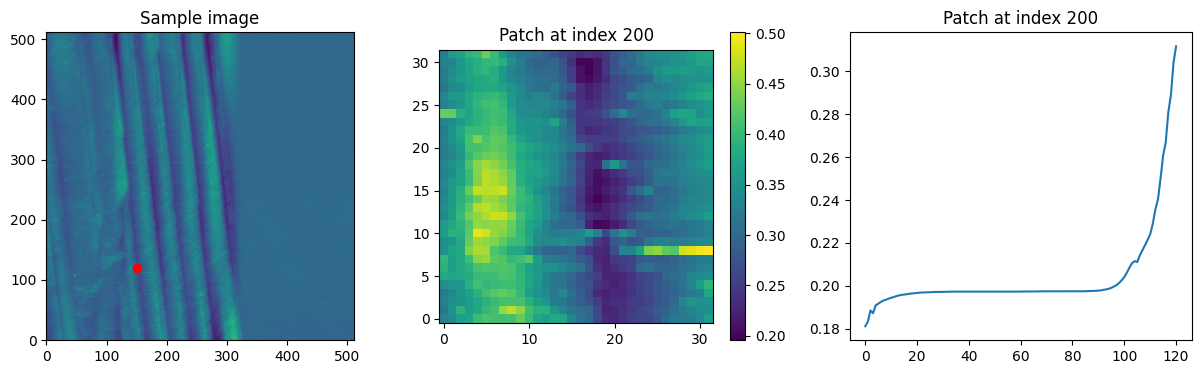

In [10]:


images, spectra, coordinates = paired_images_spectra_1(full_image, cits_obj, hyperspectra, window_size = WS,
                                                       coordinate_step = 15, image_norm=False, spectra_norm = False)

print(images.shape, spectra.shape, coordinates.shape)
in_dim = images[0].shape  # Input dimensions (image height and width)
out_dim = len(spectra[0])  # Output dimensions (spectra length)

print(coordinates[0])
fig, ax = plt.subplots(1, 3, figsize = (15, 4))


idx = 200

ax[0].imshow(full_image, origin = 'lower')
ax[0].scatter(coordinates[idx, 1], coordinates[idx, 0], c ="r")
ax[0].set_title("Sample image")


im = ax[1].imshow(images[idx], origin = 'lower')
fig.colorbar(im, ax=ax[1])
ax[1].set_title(f"Patch at index {idx}")
ax[2].plot(spectra[idx])
ax[2].set_title(f"Patch at index {idx}")

plt.show()

In [11]:
# coordinates are reversed.
swap_coordinates = coordinates.copy()
swap_coordinates = swap_coordinates[:, [1, 0]]
swap_coordinates.shape

(1024, 2)

In [12]:
images_all = images.copy()
spectra_all = spectra.copy()
swap_coordinates_all = swap_coordinates.copy()


# Models training loop setup

In [13]:
WS = 32
WS_init = 4
d_WS = 4
n_epochs_im2spec = 100
n_epochs_error = 100
error_type = "L1" # "L1", "L2", or "cos"

#append_image_type = 'interpolate'
use_swa = True
latent_dim = 5
last_swa_epochs = 0.1

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model_types = ['im2spec', 'im2spec_attn', 'FNO', 'FNO_attn']
append_image_types = [default_append_image_type(model_type) for model_type in model_types] #pad, interpolate

scale_type = "multi_scale"  # "single_scale" or "multi_scale"


In [14]:

# initialize variables for the acquisition loop
acquisition_iterations = 1  # number of iterations
num_new_points = 5  # points per iteration
acquisition_method = "distance"  # or "random"

# Run loop

len(images): 1024
len(indices_train): 153
len(indices_test): 871

Training model: im2spec with append_image_type: pad
Augmented images shape: (1224, 32, 32), Augmented spectra shape: (1224, 121), Augmented coordinates shape: (1224, 3)
Augmented images shape: (6968, 32, 32), Augmented spectra shape: (6968, 121), Augmented coordinates shape: (6968, 3)
Current augmented train data: 1224, Current augmented test data: 6968


 92%|█████████▏| 92/100 [00:07<00:00, 13.13it/s, train_loss=0.0013, val_loss=0.0014]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:06<00:00, 14.76it/s, train_loss=0.0273, val_loss=0.0288]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:06<00:00, 14.77it/s, train_loss=0.0281, val_loss=0.0270]


Augmented images shape: (8192, 32, 32), Augmented spectra shape: (8192, 121), Augmented coordinates shape: (8192, 3)


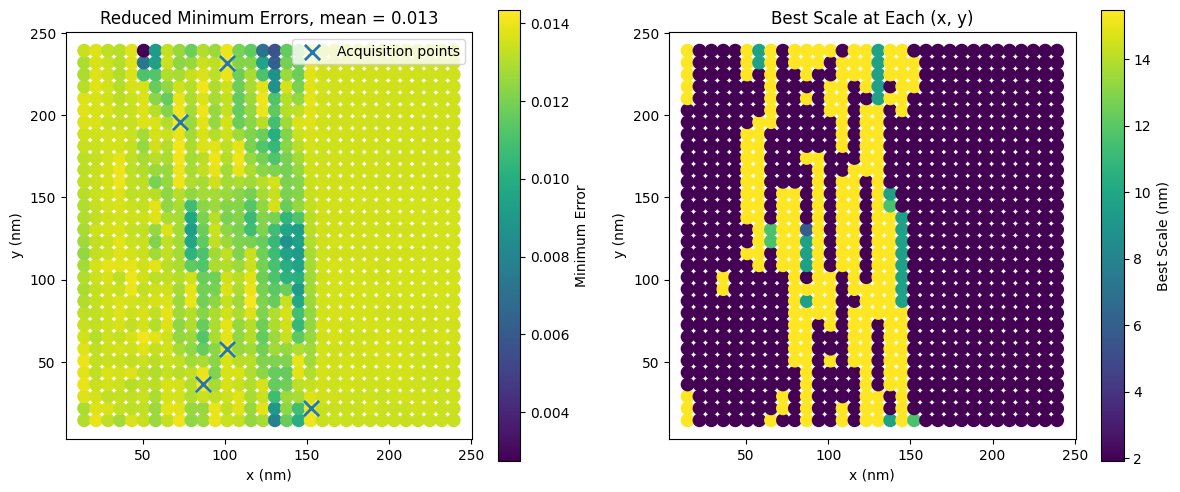

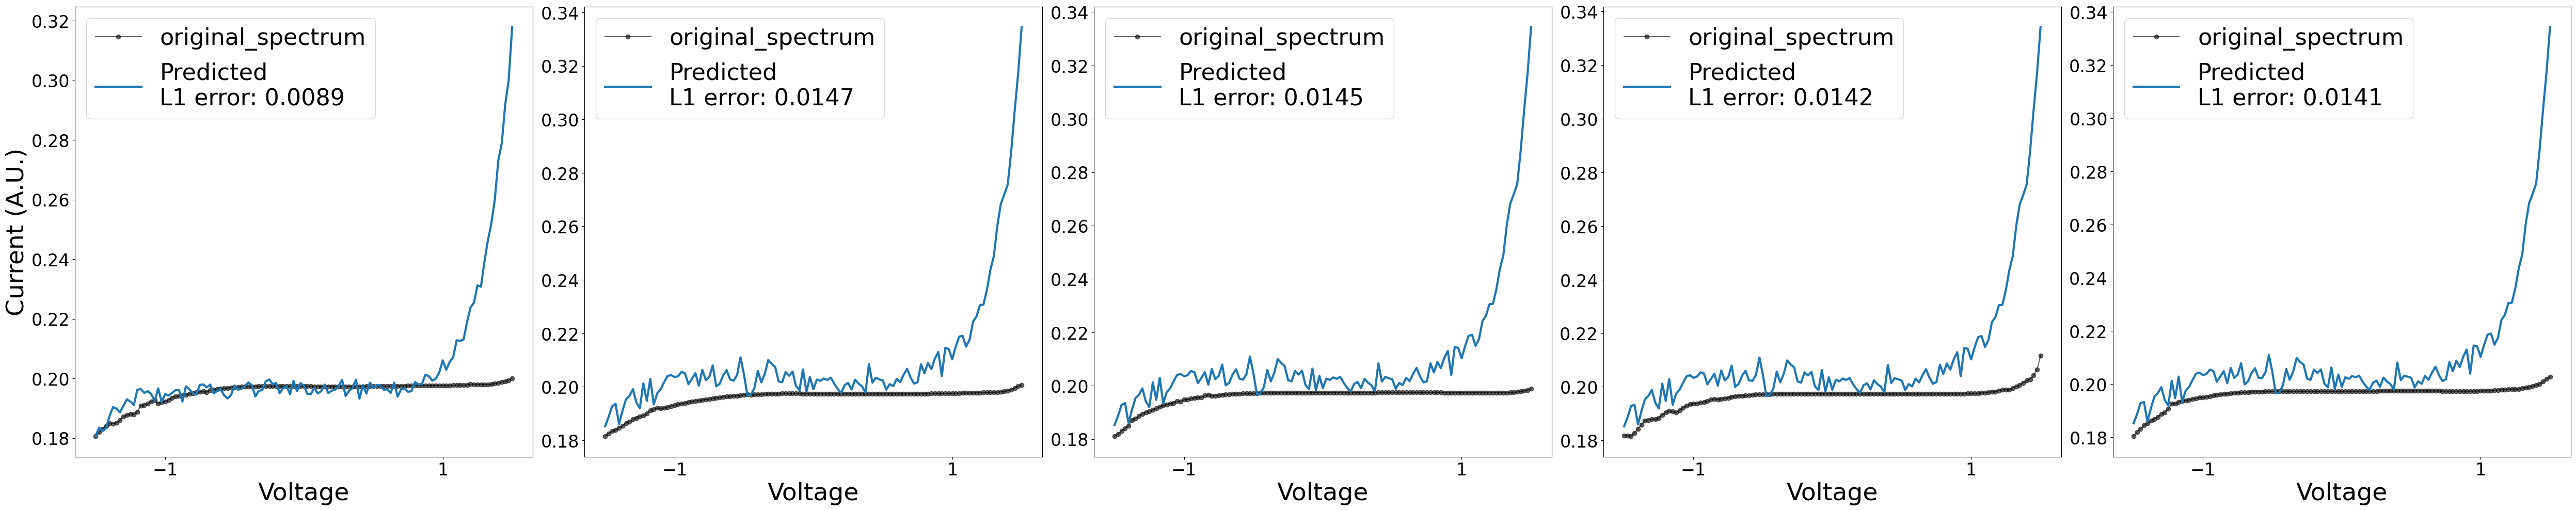

Train indices set size: 153, Test indices set size: 871

Training model: im2spec_attn with append_image_type: pad
Augmented images shape: (1224, 32, 32), Augmented spectra shape: (1224, 121), Augmented coordinates shape: (1224, 3)
Augmented images shape: (6968, 32, 32), Augmented spectra shape: (6968, 121), Augmented coordinates shape: (6968, 3)
Current augmented train data: 1224, Current augmented test data: 6968


 92%|█████████▏| 92/100 [00:08<00:00, 11.04it/s, train_loss=0.0013, val_loss=0.0014]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:07<00:00, 12.26it/s, train_loss=0.1114, val_loss=0.0313]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:08<00:00, 12.28it/s, train_loss=0.0338, val_loss=0.0313]


Augmented images shape: (8192, 32, 32), Augmented spectra shape: (8192, 121), Augmented coordinates shape: (8192, 3)


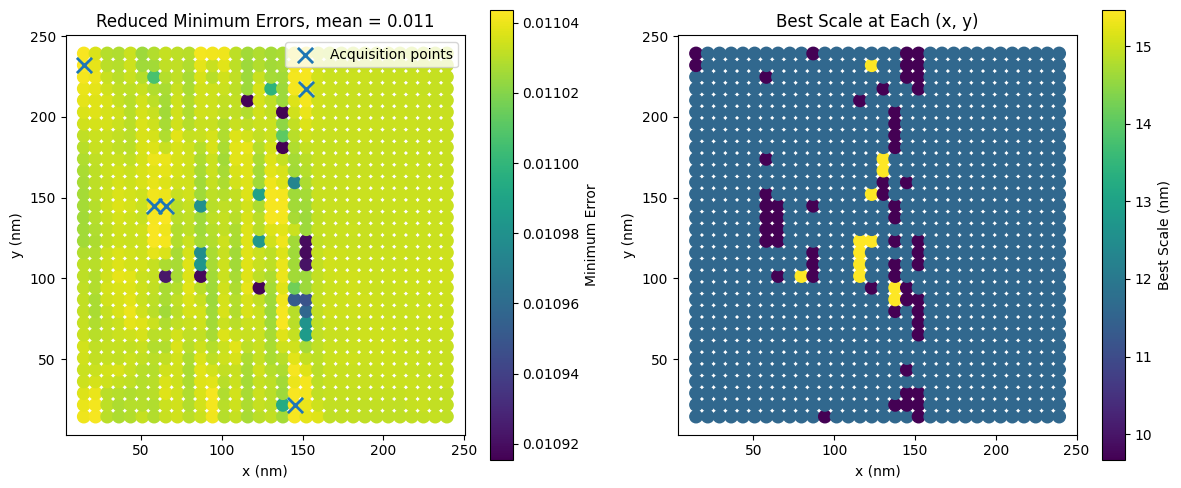

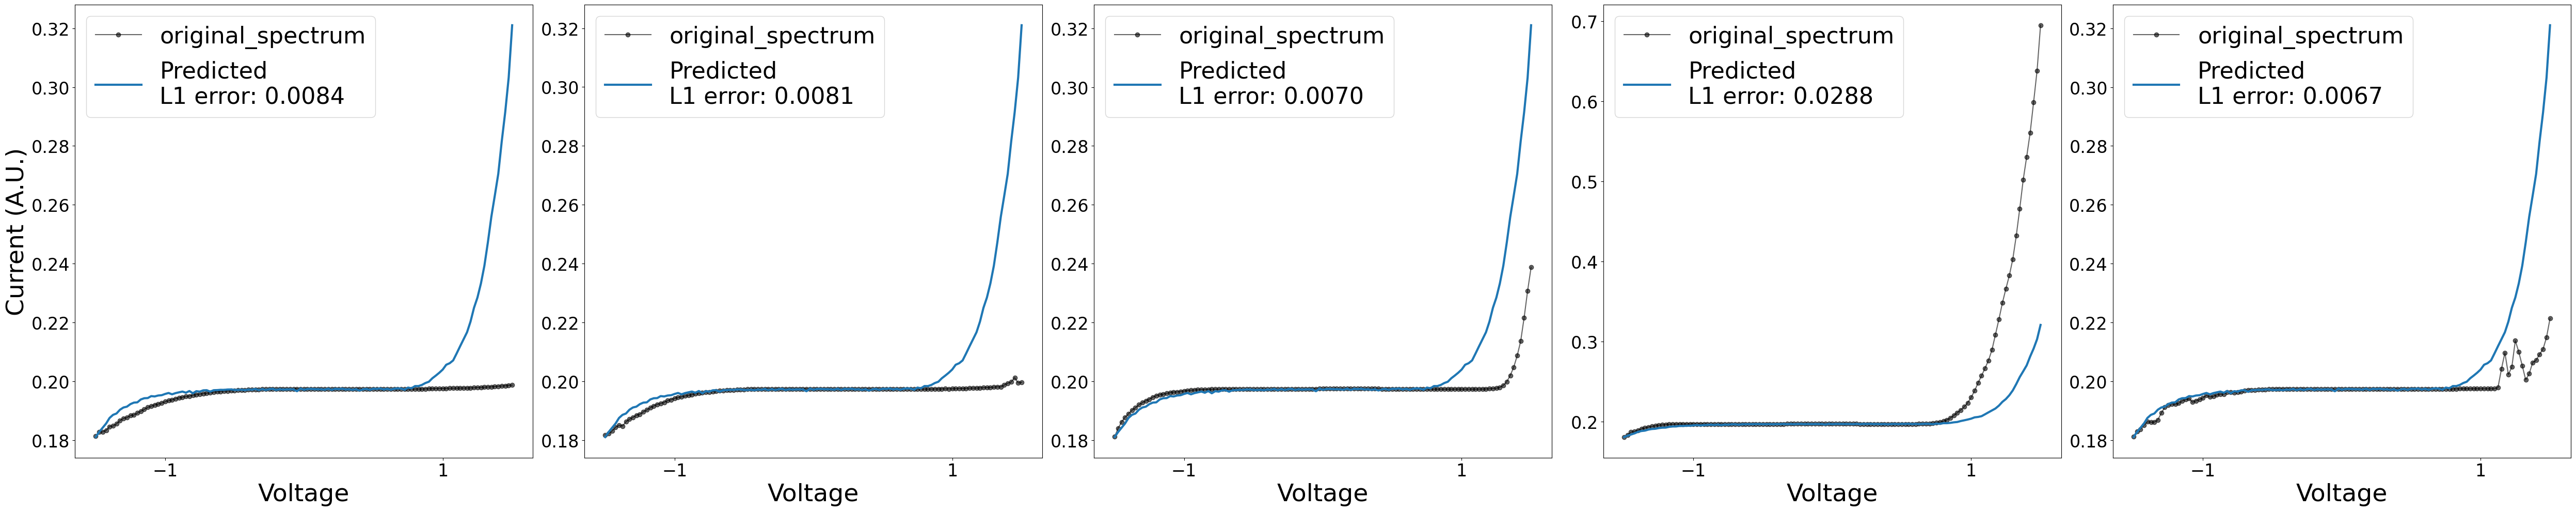

Train indices set size: 153, Test indices set size: 871

Training model: FNO with append_image_type: interpolate
Augmented images shape: (1224, 32, 32), Augmented spectra shape: (1224, 121), Augmented coordinates shape: (1224, 3)
Augmented images shape: (6968, 32, 32), Augmented spectra shape: (6968, 121), Augmented coordinates shape: (6968, 3)
Current augmented train data: 1224, Current augmented test data: 6968


 92%|█████████▏| 92/100 [00:13<00:01,  6.91it/s, train_loss=0.0014, val_loss=0.0015]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.28it/s, train_loss=0.0314, val_loss=0.0380]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:13<00:00,  7.25it/s, train_loss=0.0317, val_loss=0.0378]


Augmented images shape: (8192, 32, 32), Augmented spectra shape: (8192, 121), Augmented coordinates shape: (8192, 3)


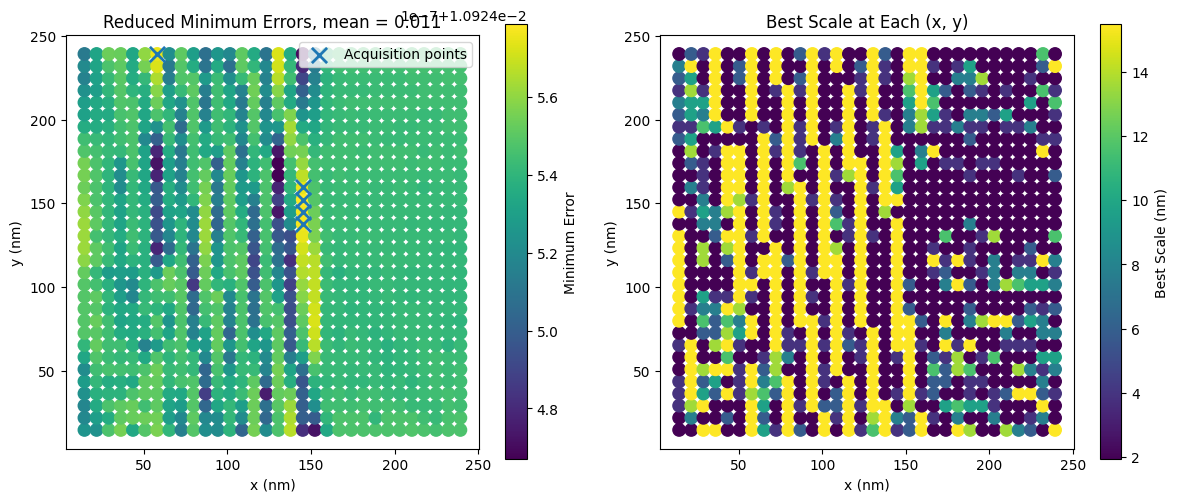

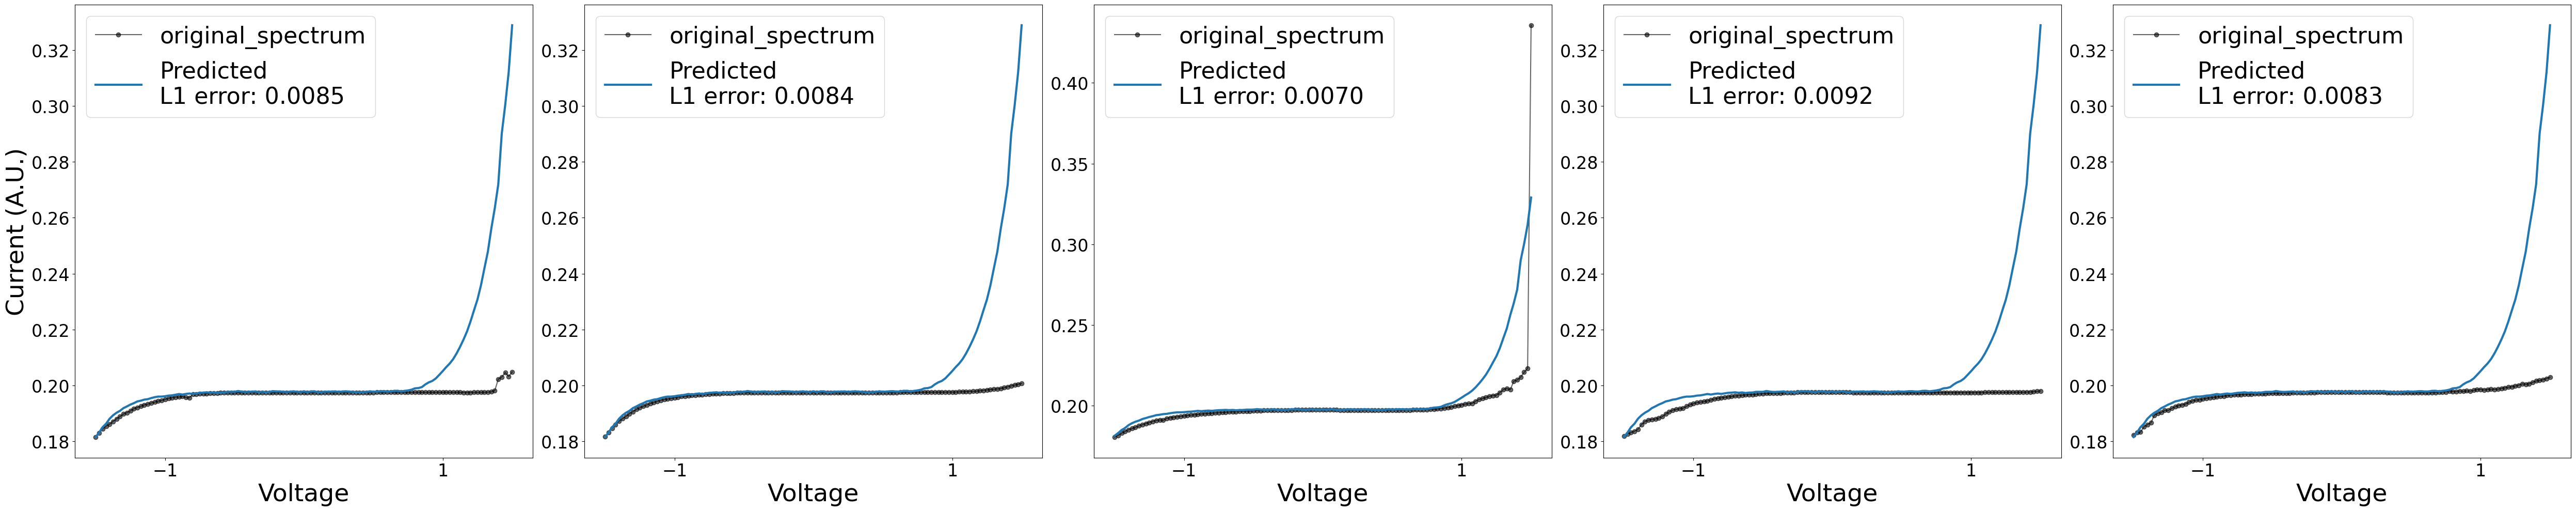

Train indices set size: 153, Test indices set size: 871

Training model: FNO_attn with append_image_type: interpolate
Augmented images shape: (1224, 32, 32), Augmented spectra shape: (1224, 121), Augmented coordinates shape: (1224, 3)
Augmented images shape: (6968, 32, 32), Augmented spectra shape: (6968, 121), Augmented coordinates shape: (6968, 3)
Current augmented train data: 1224, Current augmented test data: 6968


 92%|█████████▏| 92/100 [00:15<00:01,  5.91it/s, train_loss=0.0014, val_loss=0.0017]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:14<00:01,  6.37it/s, train_loss=0.0339, val_loss=0.0377]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:15<00:00,  6.38it/s, train_loss=0.0338, val_loss=0.0570]


Augmented images shape: (8192, 32, 32), Augmented spectra shape: (8192, 121), Augmented coordinates shape: (8192, 3)


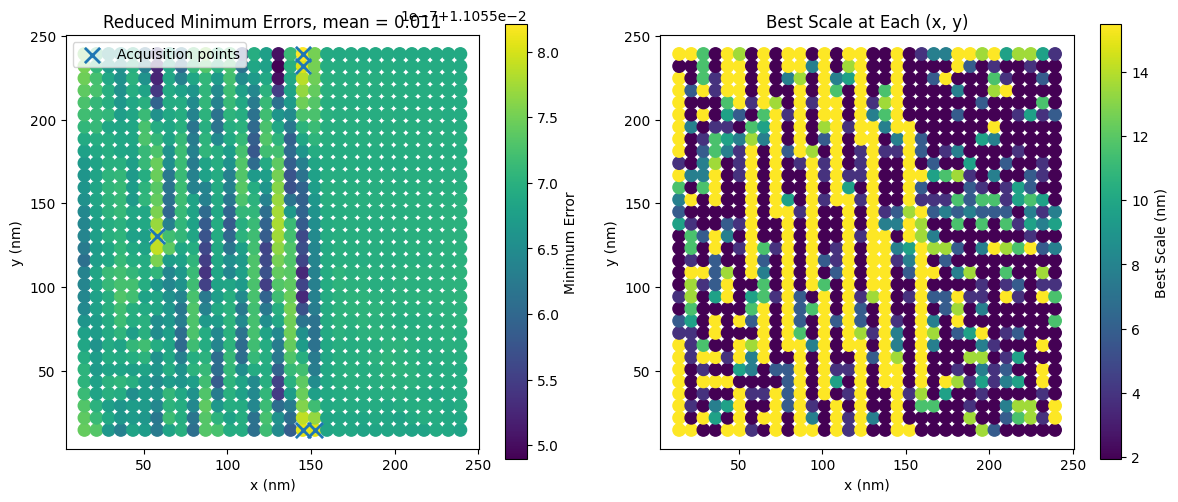

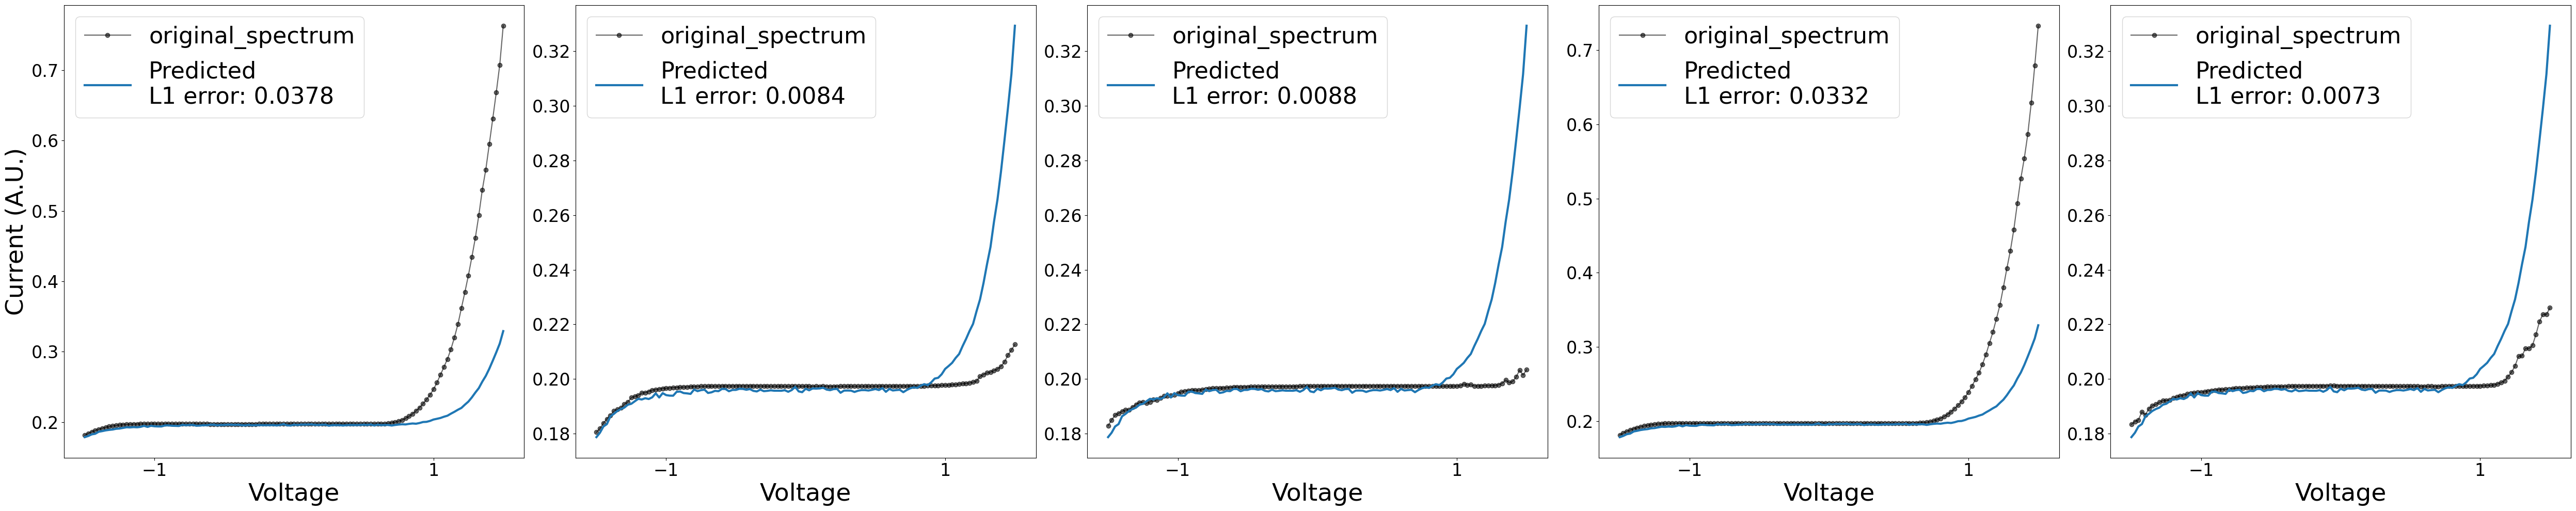

Train indices set size: 153, Test indices set size: 871


In [21]:
import numpy as np
from sklearn.model_selection import train_test_split



# original indices for the full dataset
original_indices = np.arange(len(images_all))
indices_train, indices_test = train_test_split(original_indices, train_size=0.15, random_state=42)

output_dict = {
    "reduced_errors": [],
    "reduced_errors_im2spec": [],
    "reduced_scales": [],
    "train_indices": [],
    "test_indices": [],
    "im2spec_test_mismatches": [],
    "pred_error_test": [],
    "predicted_errors_all": []
}



print("len(images):", len(images))
print("len(indices_train):", len(indices_train))
print("len(indices_test):", len(indices_test))


for model_type, append_image_type in zip(model_types, append_image_types):
    print(f"\nTraining model: {model_type} with append_image_type: {append_image_type}")


    current_images_train, current_spectra_train, coordinates_train = augment_images_by_indices(indices_train, images_all, spectra_all, swap_coordinates_all, WS_init, WS, d_WS, append_image_type=append_image_type, scale_type=scale_type)
    images_test_aug, spectra_test_aug, coordinates_test = augment_images_by_indices(indices_test, images_all, spectra_all, swap_coordinates_all, WS_init, WS, d_WS, append_image_type=append_image_type, scale_type=scale_type)

    print(f"Current augmented train data: {current_images_train.shape[0]}, Current augmented test data: {images_test_aug.shape[0]}")


    # ---------------- Datasets ----------------

    # recreate datasets
    im2spec_al_training_dataset = TensorDataset(
        torch.tensor(current_images_train, dtype=torch.float32),
        torch.tensor(current_spectra_train, dtype=torch.float32),
    )

    # validation dataset
    im2spec_al_val_dataset = TensorDataset(
        torch.tensor(images_test_aug, dtype=torch.float32),
        torch.tensor(spectra_test_aug, dtype=torch.float32),
    )


    # ------------------- IM2spec model training -------------------

    imspec_model = get_model(model_type, in_dim, out_dim, latent_dim=latent_dim, device=device)

    imspec_model, al_im2spec_train_loss, al_im2spec_val_loss = train_model(
        imspec_model,
        im2spec_al_training_dataset,
        n_batches=6,
        lr=1e-3,
        patience= 10,
        n_epochs=n_epochs_im2spec, #reduced epochs for faster retraining
        partial_train=False,
        val_dataset=None, # im2spec_al_val_dataset,
        use_swa=use_swa,
        last_swa_epochs = last_swa_epochs
    )


    # ------------------------- Error model training -------------------------

    # estimate errors again with the appended dataset
    error_mean_al, _, _ = err_estimation(imspec_model, current_images_train, current_spectra_train, error_type=error_type)
    error_norm = Norm_0to1(data=error_mean_al)
    error_mean_al = error_norm.normalize(error_mean_al)
    error_targets_al = error_mean_al.astype(np.float32).reshape(-1, 1)

    # retrain and reinitialize error model
    with torch.no_grad():
        latent_dim = imspec_model.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]
    error_model = CustomDecoder(encoder=imspec_model.encoder, embed_dim=latent_dim, target_size=1).to(device)

    error_al_training_dataset = TensorDataset(
        torch.tensor(current_images_train, dtype=torch.float32),
        torch.tensor(error_targets_al, dtype=torch.float32),
    )


    error_model, al_error_train_loss, al_error_val_loss = train_model(
        error_model,
        error_al_training_dataset,
        n_batches=6,
        lr=1e-3,
        patience=10,
        n_epochs=n_epochs_error,
        partial_train=True,
        val_dataset=  None, # error_al_val_dataset,
        use_swa=use_swa,
        last_swa_epochs = last_swa_epochs
    )



    # ------------- Test set evaluation for error model and im2spec model --------------

    # test set errors to evaluate error model. This is only for benchmarking and cannot be used for acquisition since it requires knowledge of the true errors, which we don't have in practice.
    error_mean_test_al, _, _ = err_estimation(imspec_model, images_test_aug, spectra_test_aug, error_type=error_type)
    error_targets_test_al = error_mean_test_al.astype(np.float32).reshape(-1, 1)
    output_dict["im2spec_test_mismatches"].append(error_mean_test_al.flatten())

    # Re-predict errors on the entire dataset with the newly trained error_model
    predicted_errors_test = predict_spectra(error_model, images_test_aug, ensemble=False)
    predicted_errors_test = error_norm.denormalize(predicted_errors_test)
    predicted_errors_test = np.clip(predicted_errors_test, 0, None) # Clip negative errors
    output_dict["pred_error_test"].append(predicted_errors_test.flatten())



    # ---------------------- Compute errors for the entire augmented dataset ----------------------

    images_all_aug, spectra_all_aug, scale_coordinates = augment_images_by_indices(original_indices, images_all, spectra_all, swap_coordinates_all, WS_init, WS, d_WS, append_image_type=append_image_type, scale_type=scale_type)

    error_im2spec_al, _, _ = err_estimation(imspec_model, images_all_aug, spectra_all_aug, error_type=error_type)
    error_im2spec_al = error_im2spec_al.flatten()




    # Re-predict errors on the entire dataset with the newly trained error_model
    predicted_errors_current_iter = predict_spectra(error_model, images_all_aug, ensemble=False)
    predicted_errors_current_iter = error_norm.denormalize(predicted_errors_current_iter)
    predicted_errors_current_iter = np.clip(predicted_errors_current_iter, 0, None) # Clip negative errors


    #  ---------------------------------- Reduced errors and scales ----------------------------------
    reduced_errors, reduced_coords = reduce_errors_and_coords(predicted_errors_current_iter, scale_coordinates)
    reduced_errors_im2spec = error_im2spec_al[find_row_indices(scale_coordinates, reduced_coords)]  # useful only for benchmarking. cannot use for acquisition since it requires knowledge of the true errors, which we don't have in practice.


    reduced_errors_test = reduced_errors[indices_test]
    output_dict["reduced_errors"].append(reduced_errors)
    output_dict["reduced_errors_im2spec"].append(reduced_errors_im2spec)
    output_dict["reduced_scales"].append(reduced_coords[:, 2])
    output_dict["train_indices"].append(indices_train.copy())
    output_dict["test_indices"].append(indices_test.copy())
    output_dict["predicted_errors_all"].append(predicted_errors_current_iter.flatten())



# ---------------------- Acquisition of new points based on the acquisition method ----------------------

    if acquisition_method == "distance":

        aq_ind, aq_vals = distance_acq_fn(
            reduced_errors, # Pass full errors
            beta=1,
            lambda_=1,
            sample_next_points=num_new_points,
            exclude_indices=indices_train.reshape(-1) # Exclude based on positional indices
        )

    elif acquisition_method == "random":

        aq_ind = np.random.choice(
            indices_test,
            size=num_new_points,
            replace=False
        )
    else:
        raise ValueError(f"Unknown acquisition method: {acquisition_method}")

    plot_reduced_errors_and_scales(reduced_errors, reduced_coords, aq_indices = aq_ind, nm_per_pixel=nm_per_pixel)

    spectra_to_plot = []
    predicted_spectra_to_plot = []
    error_values_to_plot = []

    for ind in aq_ind:
        ind_aug_set = find_row_indices(scale_coordinates, reduced_coords[ind:ind+1])  # Find the index in the augmented dataset corresponding to the reduced coordinate
        ind_aug_set = ind_aug_set[0]  # Extract the index from the array
        # Acquisition point
        next_coordinate = scale_coordinates[ind_aug_set]
        predicted_spectrum = predict_spectra(imspec_model, images_all_aug[ind_aug_set:ind_aug_set+1], ensemble = False)

        spectral_error, _, _ = err_estimation(imspec_model, images_all_aug[ind_aug_set:ind_aug_set+1], spectra_all_aug[ind_aug_set:ind_aug_set+1], error_type=error_type)
        # error_log.append(spectral_error.mean())
        spectra_to_plot.append(spectra_all_aug[ind_aug_set])
        predicted_spectra_to_plot.append(predicted_spectrum)
        error_values_to_plot.append(spectral_error.mean())

    plot_spectra_grid(
        spectra_to_plot, predicted_spectra_to_plot, error_values_to_plot, error_type, voltages=cits_obj.V_range
    )


    # # update train/test splits
    # indices_train = np.concatenate([indices_train, aq_ind]).ravel()

    # indices_test = indices_test[~np.isin(indices_test, aq_ind)]
    print(f"Train indices set size: {len(indices_train)}, Test indices set size: {len(indices_test)}")

# additonal saving functions

In [16]:
# folder = "data/active_learning_results" if not running_on_colab() else "./data/active_learning_results"
# os.makedirs(folder, exist_ok=True)
# filename = f"all_models_{model_type}_{error_type}_WS{WS}_latent{latent_dim}_append{append_image_type}_{acquisition_iterations}iters_{num_new_points}pts_{acquisition_method}acq.h5"
# output_file = os.path.join(folder, filename)
# save_h5_ragged(output_file, output_dict)

In [17]:
# train_indices_arr = output_dict["train_indices"]
# test_indices_arr = output_dict["test_indices"]
# reduced_errors_arr = np.array(output_dict["reduced_errors_im2spec"])

# test_reduced_errors = [reduced_errors_arr[i][test_indices_arr[i]] for i in range(acquisition_iterations)]

# mean_test_reduced_errors = [np.mean(test_reduced_errors[i]) for i in range(acquisition_iterations)]

# fig, ax = plt.subplots(figsize=(8, 5))
# ax.plot(np.arange(acquisition_iterations)*num_new_points, mean_test_reduced_errors, marker='o')
# plt.show()
